# Tech Layoffs 2026 Analysis

### Import Library

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load Data

In [13]:
df = pd.read_csv(r"F:\Pandas Tutorial\Tech Layoff Analysist\tech_layoffs_2026_tracker.csv")
df.head()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026"
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026"
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026"


### Data Cleaning

In [6]:
# cek missing value 

df.isnull().sum()

company                          0
layoff_date                      0
jobs_cut                         0
pct_workforce_cut                0
sector                           0
country                          0
hq_city                          0
ai_cited                         0
reason_stated                    0
company_revenue_2025_bn          0
pre_layoff_headcount             0
stock_change_day_pct             0
simultaneous_ai_investment_bn    0
roles_most_affected              0
replacement_roles                0
ceo_quote                        0
layoffs_2024                     0
layoffs_2025                     0
verified_source                  0
month                            0
quarter                          0
region                           0
layoff_size_category             0
stock_reaction                   0
laid_off_vs_headcount_pct        0
data_as_of                       0
dtype: int64

In [10]:
# id column still string we convert to number

df['jobs_cut'] = pd.to_numeric(df['jobs_cut'], errors = 'coerce')

In [15]:
# change date format

df['layoff_date'] = pd.to_datetime(df['layoff_date'])

### Exploration Data Analysis

In [46]:
df.head(2)

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"


### Exploraroty Data Analysis

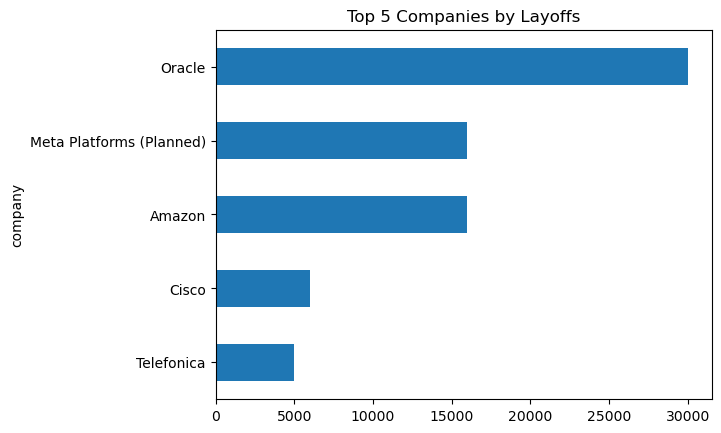

In [28]:
top_companies = df.groupby('company')['jobs_cut'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(5)

top_companies = top_companies.iloc[::-1]

top_companies.plot(kind='barh')
plt.title('Top 5 Companies by Layoffs')
plt.show()

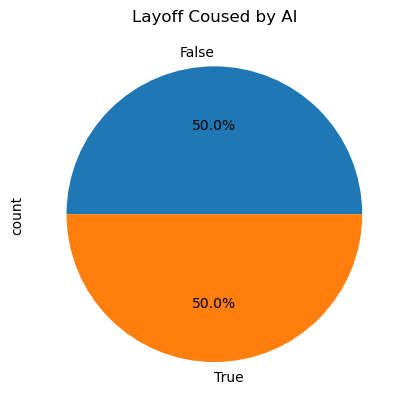

In [40]:
ai_counts = df['ai_cited'].value_counts()

ai_counts.plot(kind = 'pie', autopct='%1.1f%%')
plt.title('Layoff Coused by AI')
plt.show()

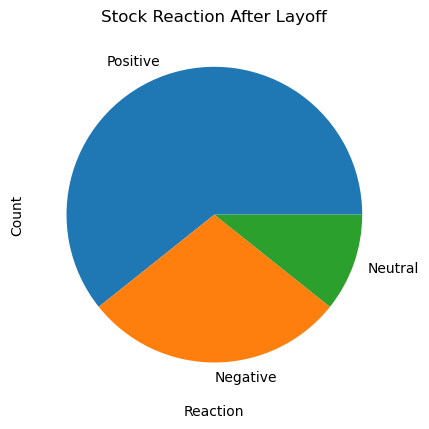

In [56]:
df['stock_reaction'].value_counts().plot(kind = 'pie')
plt.title('Stock Reaction After Layoff')
plt.xlabel('Reaction')
plt.ylabel('Count')
plt.show()

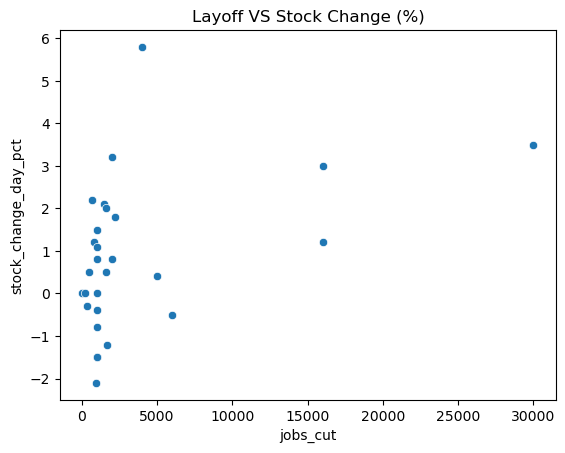

In [63]:
sns.scatterplot(
    x='jobs_cut', 
    y= 'stock_change_day_pct', data = df)
plt.title('Layoff VS Stock Change (%)')
plt.show()

In [68]:
df[['jobs_cut','stock_change_day_pct', 'pct_workforce_cut']].corr()

,jobs_cut,stock_change_day_pct,pct_workforce_cut
jobs_cut,1.000000,0.412532,0.125598
stock_change_day_pct,0.412532,1.000000,0.294795
pct_workforce_cut,0.125598,0.294795,1.000000


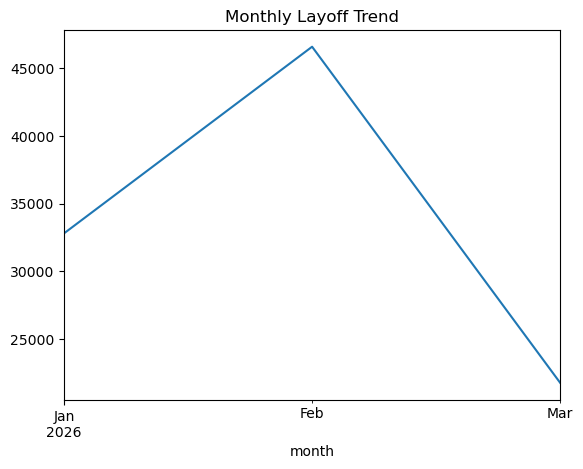

In [78]:
df['layoff_date'] = pd.to_datetime(df['layoff_date'])
df['Month'] = df['layoff_date'].dt.to_period('M')
monthly_layoffs = df.groupby('month')['jobs_cut'].sum()

monthly_layoffs.plot()
plt.title('Monthly Layoff Trend')
plt.show()

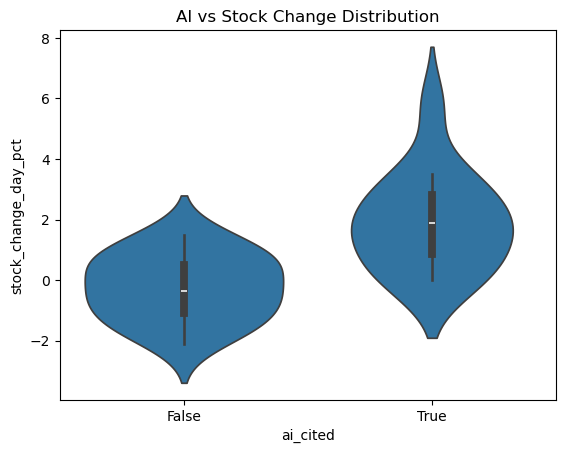

In [82]:
sns.violinplot(x='ai_cited', y='stock_change_day_pct', data=df)
plt.title('AI vs Stock Change Distribution')
plt.show()

In [92]:
df.to_excel(r'F:\Pandas Tutorial/tech_analysis_data.xlsx', index = False)